<a href="https://colab.research.google.com/github/cahyanikartika017-boop/UTS_BIG_DATA/blob/main/uts_Kartika_Cahyani_14022300049.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
pip install google-play-scraper

In [12]:
from google_play_scraper import reviews, Sort
import csv

result, _ = reviews(
    'com.bpjstku',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=100,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'

with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
    writer.writeheader()
    for review in result:
        writer.writerow({
            'userName': review['userName'],
            'score': review['score'],
            'at': review['at'],
            'content': review['content']
        })

print(f"Berhasil menyimpan {len(result)} ulasan ke '{filename}'")

Berhasil menyimpan 100 ulasan ke 'ulasan_google_play.csv'


In [13]:
pip install transformers pandas

In [14]:
import pandas as pd
from transformers import pipeline

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(filename)

# Display the first few rows to verify
display(df.head())

,userName,score,at,content
0,10Eki Indriyani,5,2026-05-05 02:23:43,masyaallah terimakasih jmo
1,Erwin Mulyadi,5,2026-05-05 02:19:16,g bisa kebuka trus aplikasi nya
2,Sak Ciu,5,2026-05-05 02:14:15,cepat dan mudah
3,Buyung Anggara,1,2026-05-05 02:12:08,kenapa sih Jamsostek mempersulit orang untuk a...
4,Aienur Ridho,5,2026-05-05 02:08:03,aplikasi terus berhenti


In [19]:
# Inisialisasi pipeline dengan model yang BENAR
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier",
    tokenizer="w11wo/indonesian-roberta-base-sentiment-classifier"
)

# Fungsi untuk mendapatkan sentimen
def get_sentiment(text):
    if pd.isna(text):
        return None, None
    result = sentiment_pipeline(text[:512])[0]  # RoBERTa punya batas 512 token
    return result['label'], result['score']

# Terapkan ke DataFrame
df[['sentiment_label', 'sentiment_score']] = df['content'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

# Tampilkan hasil
display(df.head())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,userName,score,at,content,sentiment_label,sentiment_score
0,10Eki Indriyani,5,2026-05-05 02:23:43,masyaallah terimakasih jmo,neutral,0.640901
1,Erwin Mulyadi,5,2026-05-05 02:19:16,g bisa kebuka trus aplikasi nya,neutral,0.663194
2,Sak Ciu,5,2026-05-05 02:14:15,cepat dan mudah,positive,0.936908
3,Buyung Anggara,1,2026-05-05 02:12:08,kenapa sih Jamsostek mempersulit orang untuk a...,negative,0.998809
4,Aienur Ridho,5,2026-05-05 02:08:03,aplikasi terus berhenti,negative,0.951297


Let's analyze the distribution of sentiment labels.

/tmp/ipykernel_2097/4069557924.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_label', data=df, palette='viridis')


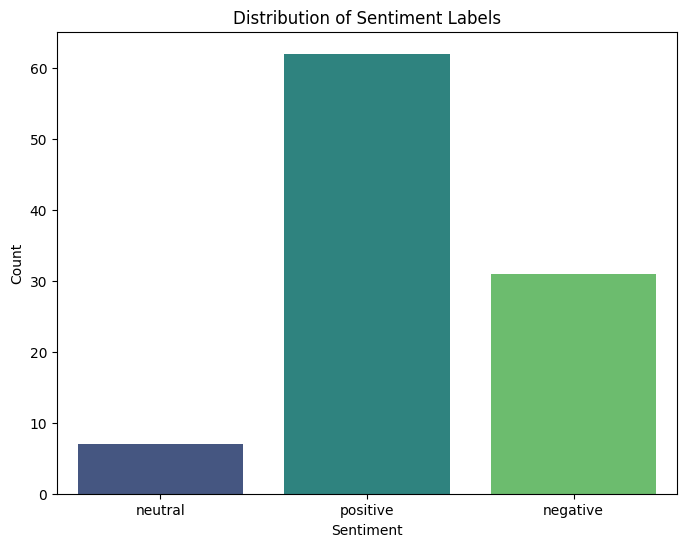

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of sentiment labels
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment_label', data=df, palette='viridis')
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()